In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/amazon_products_sales_data_cleaned.csv")

# **Dataset Overview**

In [29]:
data.shape

(42675, 17)

In [14]:
data.sample(5)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
34174,"Garmin Approach S70, 47mm, Premium GPS Golf Wa...",4.4,322.0,50.0,699.99,699.99,No Badge,Organic,No Coupon,Add to cart,2025-08-30,NaN,https://m.media-amazon.com/images/I/71dQF0WhHE...,https://www.amazon.com/Garmin-Approach-Premium...,2025-08-29 11:38:01,Wearables,0.00
1266,HP 414X Magenta High-yield Toner Cartridge | W...,4.7,650.0,900.0,307.89,307.89,No Badge,Organic,No Coupon,Add to cart,2025-09-22,NaN,https://m.media-amazon.com/images/I/71urhVp3LQ...,https://www.amazon.com/HP-W2023X-Toner-Cartrid...,2025-08-21 11:24:48,Laptops,0.00
76,Amazon Basics 9 inch Thermal Laminator Machine...,4.6,2740.0,40000.0,20.69,29.99,Best Seller,Organic,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61OJ1l3YGy...,https://www.amazon.com/Amazon-Basics-Thermal-L...,2025-08-21 11:15:00,Other Electronics,31.01
5042,​​​​PopSockets Phone Grip with Expanding Kicks...,4.6,11074.0,1000.0,7.50,9.97,No Badge,Organic,No Coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/516IryX4bn...,https://www.amazon.com/POPSOCKETS-Phone-Grip-E...,2025-08-21 11:51:58,Phones,24.77
11649,"Google Coral USB Accelerator: ML Accelerator, ...",4.6,423.0,100.0,151.04,151.04,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/41MIEI2Qhk...,https://www.amazon.com/Google-G950-01456-01-Co...,2025-08-24 22:04:58,Other Electronics,0.00


In [28]:
data.isnull().sum()

,0
product_title,0
product_rating,1024
total_reviews,1024
purchased_last_month,10511
discounted_price,2062
original_price,2062
is_best_seller,0
is_sponsored,0
has_coupon,0
buy_box_availability,14653


In [30]:
data.duplicated().sum()

np.int64(0)

**Observations**:

* Dataset contains 42675 products.  
*  Missing values mainly occur in purchases, delivery date, buy box availability and sustainability tags.
*   There is no duplicated column







# **Summary Statistics**

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

In [5]:
data.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


**Observatons**:


*   Purchases and total reviews are highly skewed.
*   More than half the products have no discount.
*   Most products are highly rated (4 - 5).

---












# **Product Review**

In [37]:
data['product_title'].nunique()

8808

In [40]:
data.groupby('product_category')['purchased_last_month'].sum()

,purchased_last_month
product_category,
Cameras,835300.0
Chargers & Cables,822150.0
Gaming,123500.0
Headphones,229550.0
Laptops,3416450.0
Networking,277050.0
Other Electronics,3425800.0
Phones,3729550.0
Power & Batteries,26151450.0


In [36]:
data.groupby('product_title').size().sort_values(ascending=False).head(10)

,0
product_title,
"Duracell Coppertop 9V Battery, 6 Count (Pack of 1), 9 Volt Battery with Long-lasting Power, All-Purpose Alkaline 9V Battery for Household and Office Devices",744
"Energizer MAX AA Batteries (16 Pack), Double A Alkaline Batteries",566
"TRX Training 6 Month On-Demand Membership - Unlimited Access to Expert-Led Workouts, Personalized Programs, Strength, Cardio & Recovery - Train Anytime",456
"KODAK 10.1 Inch WiFi Digital Picture Frame,1280x800 HD IPS Touch Screen, Electronic Smart Photo Frame with 32 GB Memory, Auto-Rotate, Instantly Share Photos/Videos Anywhere",438
"Belkin MagSafe-Compatible Charger, 3-in-1 Wireless Charging Station, Qi2-Certified 15W Wireless Charge for Apple iPhone 16 Series, Apple Watch, AirPods w/Non-Slip Base, 40W Included - Black",377
"RCA 10.1"" WiFi Digital Picture Frame Uhale App Photo Frames Electronic HD IPS Touch Screen Display with 32GB Memory LED Lights, Support USB/SD Card, Slideshow, Instantly Share Photos Videos",371
Toshiba 20TB MG10ACA20TE SATA 600GB 20in1 HDD,254
"Lenovo USI Stylus Pen, Chrome OS Support, 4,096 Levels of Pressure Sensitivity, 150 Days Battery Life, AAAA Battery, Works with Chromebook, GX81B10212,Grey",231
"Sanus Height Adjustable Speaker Stand for Sonos Era 300™ - 17"" Height Adjustment Sonos Stand Includes Carpet Spikes & Rubber Pads - Easy DIY Install Comes w/All Hardware - White",216


In [41]:
data.groupby('product_title').size().describe()

,0
count,8808.000000
mean,4.845027
std,23.667168
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,744.000000


In [43]:
data[data['product_title'] == data['product_title'].value_counts().idxmax()]

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
348,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5207.0,20000.0,25.47,25.47,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-21 11:17:40,Power & Batteries,0.00
416,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5207.0,20000.0,25.47,25.47,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-21 11:18:07,Power & Batteries,0.00
449,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5207.0,20000.0,25.47,25.47,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-21 11:18:18,Power & Batteries,0.00
517,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5207.0,20000.0,25.47,25.47,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-21 11:19:08,Power & Batteries,0.00
550,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5207.0,20000.0,25.47,25.47,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-21 11:19:21,Power & Batteries,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42200,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5262.0,20000.0,19.69,23.26,Limited time deal,Sponsored,No Coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-30 19:51:51,Power & Batteries,15.35
42279,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5262.0,20000.0,19.69,23.26,No Badge,Sponsored,No Coupon,Add to cart,2025-09-11,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-30 19:52:32,Power & Batteries,15.35
42408,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5262.0,20000.0,19.69,23.26,No Badge,Sponsored,No Coupon,Add to cart,2025-09-11,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-30 19:53:37,Power & Batteries,15.35
42513,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",4.8,5262.0,20000.0,19.69,23.26,No Badge,Sponsored,No Coupon,Add to cart,2025-09-11,NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2b...,NaN,2025-08-30 19:54:27,Power & Batteries,15.35


In [45]:
data[['product_title',
      'purchased_last_month',
      'product_rating',
      'total_reviews']].duplicated().sum()

np.int64(33561)

In [50]:
data.sort_values('discounted_price').head(20)[
    ['product_title','discounted_price','product_category']
]

,product_title,discounted_price,product_category
4349,Panasonic CR2025 3.0 Volt Long Lasting Lithium...,2.16,Power & Batteries
8202,Panasonic Cr2450 Cr 2450 Lithium 3v Battery [ ...,2.48,Power & Batteries
803,"Avery Economy View 3 Ring Binder, 1"" Round Rin...",2.49,Other Electronics
9002,"Woods Light Duty Extension Cord Wrap, Holds up...",2.97,Other Electronics
7917,"Leviton 5601-2E 15 Amp, 120/277 Volt, Decora R...",2.99,Other Electronics
1590,Casio HS-8VA Mini 6-Function Calculator | Larg...,3.59,TV & Display
6230,"Duracell 376/377 Silver Oxide Button Battery, ...",3.65,Power & Batteries
6085,"Duracell 379 Silver Oxide Button Battery, 1 Co...",3.84,Power & Batteries
3491,"SanDisk MicroSD to SD Memory Card Adapter , Black",3.86,Chargers & Cables
7345,"GE Coax Plate, 1-Port, One Wall Mounted F-Type...",3.88,Chargers & Cables


**Observations**:


*  The dataset contains 42,675 records but only 8,808 unique product titles.


*   Several products appear multiple times in the dataset, with some products occurring as many as 744 times.
*   Repeated entries are not exact duplicates; attributes such as collection timestamp, price, delivery date, review count, and promotional status vary across observations.


*   This suggests the data was collected through multiple scraping sessions, resulting in repeated snapshots of the same product over time.






**Data Validation Findings**


*   Product prices appeared reasonable when manually inspecting the lowest-priced records.
*   Several category labels did not align with the actual products, indicating possible classification errors.


*  Repeated observations of the same products were identified due to multiple scraping events and will be handled through product-level deduplication before analysis.


# **Deduplication of dataset**

In [53]:
product_data = (data.sort_values('data_collected_at').drop_duplicates(subset='product_title',keep='last'))

In [54]:
product_data.shape

(8808, 17)

In [55]:
product_data['product_category'].value_counts()

,count
product_category,
Other Electronics,2000
Laptops,1975
Phones,1453
Cameras,711
TV & Display,521
Chargers & Cables,491
Power & Batteries,368
Speakers,226
Storage,215


In [56]:
product_data['is_sponsored'].value_counts()

,count
is_sponsored,
Organic,8477
Sponsored,331


In [57]:
product_data.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,8743.000000,8743.000000,7686.000000,8384.000000,8384.000000,8384.000000
mean,4.439231,5950.139540,1377.725735,206.480524,218.463267,6.972141
std,0.300328,23914.834022,5060.500741,406.109705,423.528968,12.318945
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.300000,195.000000,100.000000,27.660000,29.990000,0.000000
50%,4.500000,898.000000,400.000000,79.000000,84.990000,0.000000
75%,4.600000,3676.000000,1000.000000,199.000000,209.992500,10.870000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


**Summary of Numerical Variables**

After removing repeated product observations, the dataset contains approximately 8.8k unique products. Ratings are generally high across products, with a median rating of 4.5 stars. Purchase counts and review volumes are highly right-skewed, indicating that a small number of products account for a large share of customer activity. More than half of the products have no discount, suggesting that discounts are not a universal sales strategy. Product prices vary widely, ranging from low-cost accessories to premium electronic devices.

# **Rating Distribution**

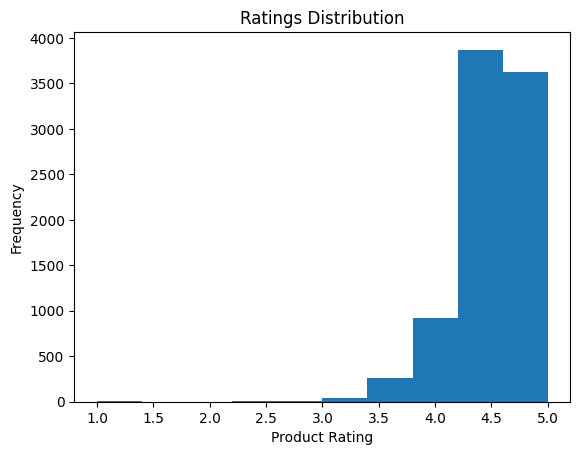

In [58]:
#Ratings Distributions
plt.hist(product_data['product_rating'].dropna())
plt.title('Ratings Distribution')
plt.xlabel('Product Rating')
plt.ylabel('Frequency')
plt.show()

Ratings are mostly between 4 to 5. so, Ratings alone may not strongly differentiate products.

---





# **Purchase Distribution**

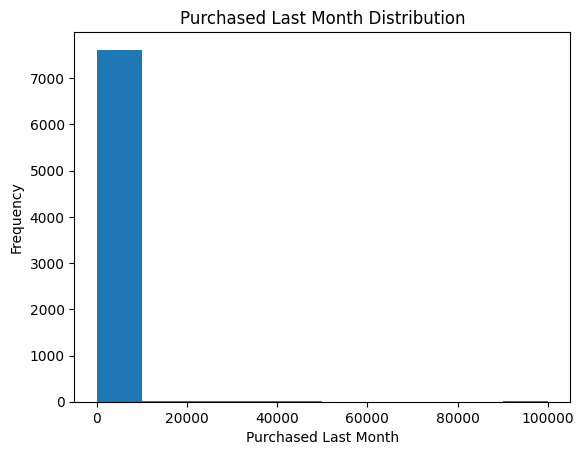

In [60]:
plt.hist(product_data['purchased_last_month'].dropna())
plt.title('Purchased Last Month Distribution')
plt.xlabel('Purchased Last Month')
plt.ylabel('Frequency')
plt.show()

purchase_last_month column is highly skewed.
A small number of products account for very large sales volumes.

---



# **Price Distribution**

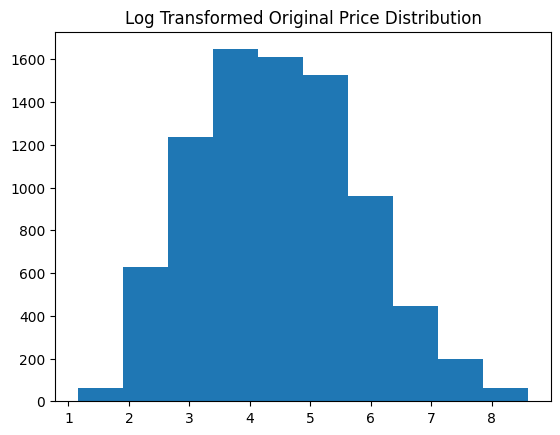

In [65]:
plt.hist(np.log1p(product_data['original_price'].dropna()))
plt.title('Log Transformed Original Price Distribution')
plt.show()

# **Correlation Heatmap**

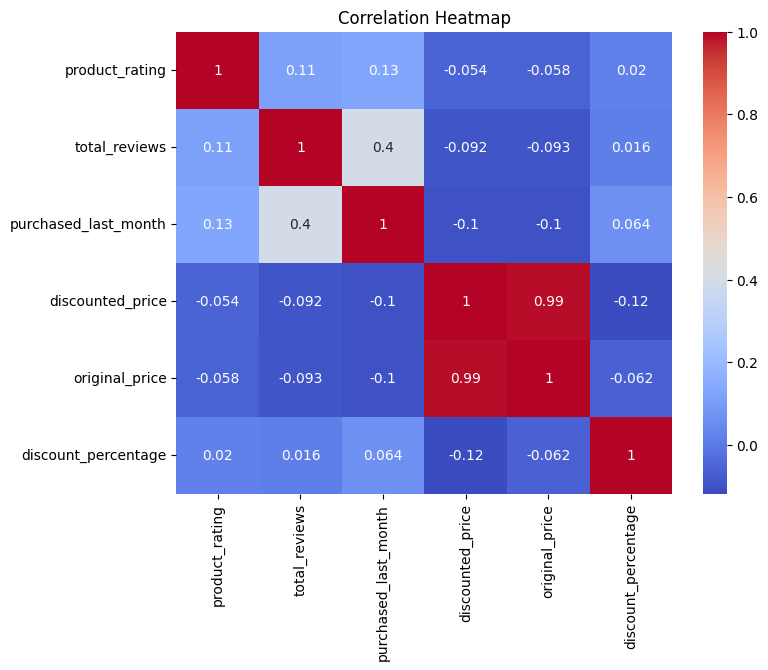

In [66]:
numeric_cols = ['product_rating','total_reviews','purchased_last_month','discounted_price','original_price','discount_percentage']
corr = product_data[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Observations**:


*   Expensive products tend to remain expensive even after discounts.
*   Discounted price is largely determined by the original price.


*   Highly rated products do not necessarily have many reviews.
*   Larger discounts do not significantly increase purchases.
*   Ratings and discount percentages have little linear relationship with purchases.



# **Top 10 Categories by Purchases**

---



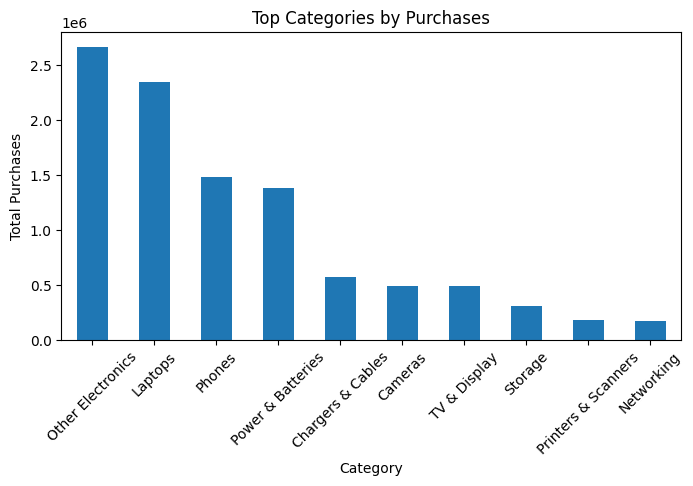

In [72]:
top_categories = (product_data.groupby('product_category')['purchased_last_month'].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(8,4))
top_categories.plot(kind='bar')
plt.title('Top Categories by Purchases')
plt.xlabel('Category')
plt.ylabel('Total Purchases')
plt.xticks(rotation=45)
plt.show()

# **Top 10 Categories by Number of Products**

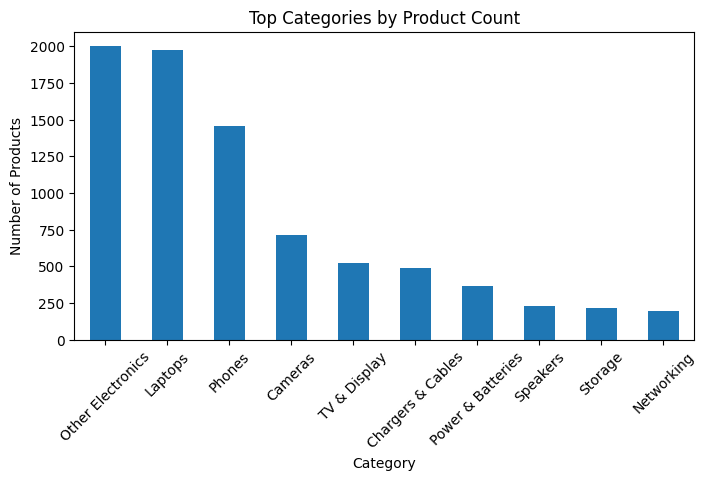

In [70]:
product_count = (product_data['product_category'].value_counts().head(10))
plt.figure(figsize=(8,4))
product_count.plot(kind='bar')
plt.title('Top Categories by Product Count')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

# **Sponsored vs Organic Purchases**

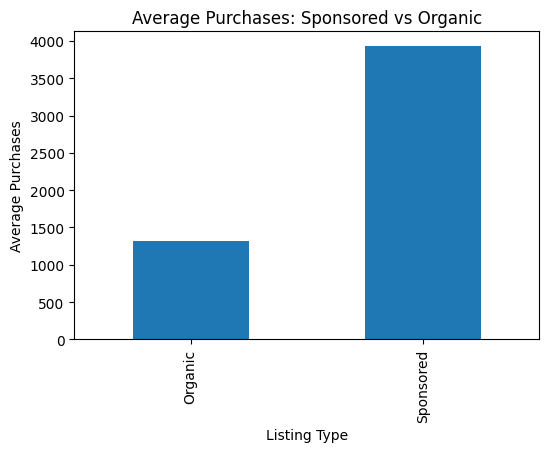

In [73]:
sponsor_sales = (product_data.groupby('is_sponsored')['purchased_last_month'].mean())
plt.figure(figsize=(6,4))
sponsor_sales.plot(kind='bar')
plt.title('Average Purchases: Sponsored vs Organic')
plt.xlabel('Listing Type')
plt.ylabel('Average Purchases')
plt.show()

# **Best Seller vs Non-Best Seller**

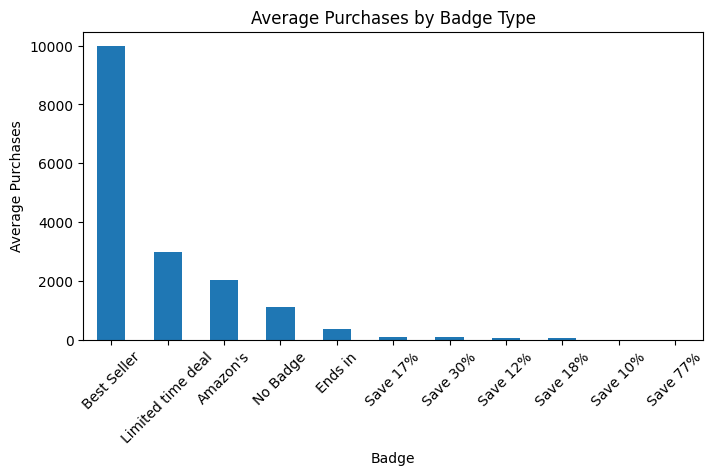

In [75]:
best_seller_sales = (
    product_data
    .groupby('is_best_seller')['purchased_last_month']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))
best_seller_sales.plot(kind='bar')
plt.title('Average Purchases by Badge Type')
plt.xlabel('Badge')
plt.ylabel('Average Purchases')
plt.xticks(rotation=45)
plt.show()

# **Discount vs Purchases (Scatter Plot)**

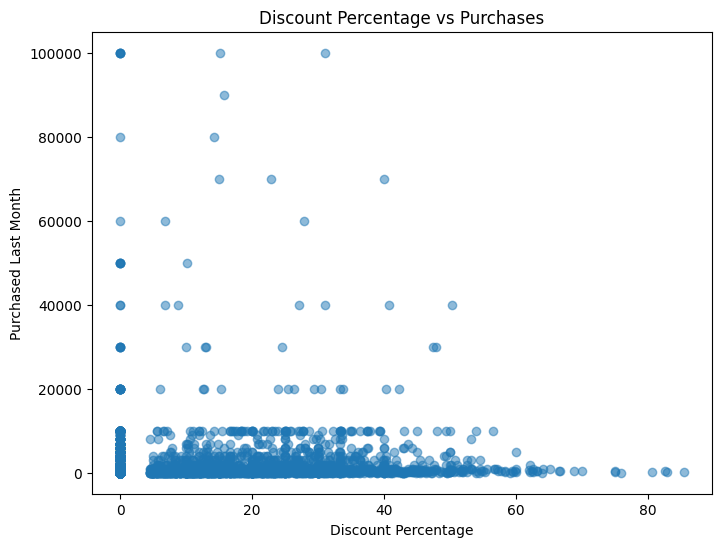

In [81]:
plt.figure(figsize=(8,6))

plt.scatter(
    product_data['discount_percentage'],
    product_data['purchased_last_month'],
    alpha=0.5
)

plt.title('Discount Percentage vs Purchases')
plt.xlabel('Discount Percentage')
plt.ylabel('Purchased Last Month')
plt.show()

# **Reviews vs Purchases**

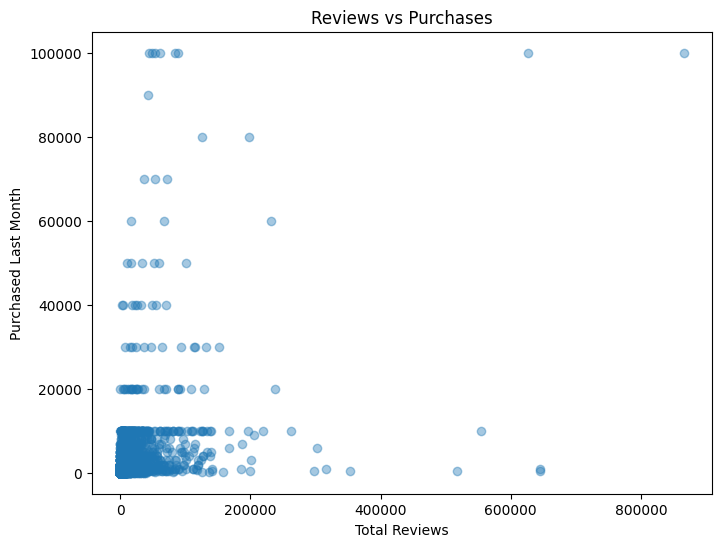

In [82]:
plt.figure(figsize=(8,6))

plt.scatter(
    product_data['total_reviews'],
    product_data['purchased_last_month'],
    alpha=0.4
)

plt.title('Reviews vs Purchases')
plt.xlabel('Total Reviews')
plt.ylabel('Purchased Last Month')
plt.show()

# **Top 10 Most Purchased Products**

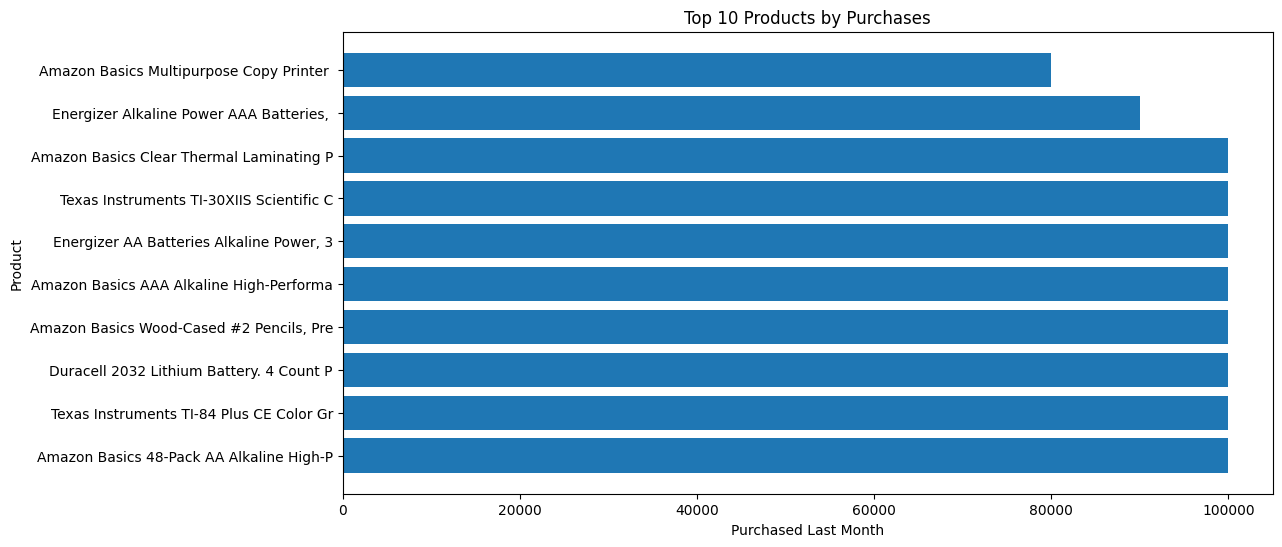

In [83]:
top_products = (
    product_data
    .sort_values('purchased_last_month', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_products['product_title'].str[:40],
    top_products['purchased_last_month']
)

plt.title('Top 10 Products by Purchases')
plt.xlabel('Purchased Last Month')
plt.ylabel('Product')
plt.show()